# 02. Baseline Modeling

이 노트북에서는 전처리된 wafer map 데이터를 사용하여 `non_pattern`과 `pattern`을 분류하는 baseline 모델을 학습한다.

Baseline 모델은 CNN과 같은 이미지 기반 딥러닝 모델을 적용하기 전에, 단순한 머신러닝 모델이 어느 정도의 기준 성능을 보이는지 확인하기 위한 목적이다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from skimage.transform import resize

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
processed_dir = Path("../data/processed")

X_train = np.load(processed_dir / "X_train_32.npy")
X_test = np.load(processed_dir / "X_test_32.npy")
y_train_encoded = np.load(processed_dir / "y_train_pattern.npy")
y_test_encoded = np.load(processed_dir / "y_test_pattern.npy")

label_info = pd.read_csv(processed_dir / "pattern_label_mapping.csv")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train_encoded shape:", y_train_encoded.shape)
print("y_test_encoded shape:", y_test_encoded.shape)

print("\nlabel mapping:")
display(label_info)

X_train shape: (54355, 32, 32, 1)
X_test shape: (118595, 32, 32, 1)
y_train_encoded shape: (54355,)
y_test_encoded shape: (118595,)

label mapping:


,class_index,class_name
0,0,non_pattern
1,1,pattern


In [5]:
print("Train label distribution:")
print(pd.Series(y_train_encoded).value_counts().sort_index())

print("\nTest label distribution:")
print(pd.Series(y_test_encoded).value_counts().sort_index())

Train label distribution:
0    36730
1    17625
Name: count, dtype: int64

Test label distribution:
0    110701
1      7894
Name: count, dtype: int64


In [6]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

X_train_flat shape: (54355, 1024)
X_test_flat shape: (118595, 1024)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_flat, y_train_encoded)

y_pred_logistic = logistic_model.predict(X_test_flat)

print("Logistic Regression Classification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_logistic,
    target_names=label_info["class_name"].tolist()
))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_logistic))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model

Logistic Regression Classification Report:
              precision    recall  f1-score   support

 non_pattern       0.97      0.56      0.71    110701
     pattern       0.10      0.72      0.18      7894

    accuracy                           0.57    118595
   macro avg       0.54      0.64      0.45    118595
weighted avg       0.91      0.57      0.67    118595

Confusion Matrix:
[[61863 48838]
 [ 2172  5722]]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_flat, y_train_encoded)

y_pred_rf = rf_model.predict(X_test_flat)

print("Random Forest Classification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_rf,
    target_names=label_info["class_name"].tolist()
))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_rf))

# Random Forest는 Logistic Regression보다 pattern precision을 올리면서 recall을 어느 정도 유지하는가?

Random Forest Classification Report:
              precision    recall  f1-score   support

 non_pattern       0.95      0.30      0.46    110701
     pattern       0.07      0.79      0.14      7894

    accuracy                           0.33    118595
   macro avg       0.51      0.54      0.30    118595
weighted avg       0.89      0.33      0.43    118595

Confusion Matrix:
[[33149 77552]
 [ 1672  6222]]


In [9]:
rf_model_plain = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model_plain.fit(X_train_flat, y_train_encoded)

y_pred_rf_plain = rf_model_plain.predict(X_test_flat)

print("Random Forest without class_weight:")
print(classification_report(
    y_test_encoded,
    y_pred_rf_plain,
    target_names=label_info["class_name"].tolist()
))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_rf_plain))

Random Forest without class_weight:
              precision    recall  f1-score   support

 non_pattern       0.96      0.32      0.48    110701
     pattern       0.08      0.79      0.14      7894

    accuracy                           0.35    118595
   macro avg       0.52      0.56      0.31    118595
weighted avg       0.90      0.35      0.46    118595

Confusion Matrix:
[[35633 75068]
 [ 1661  6233]]


In [10]:
y_proba_rf = rf_model.predict_proba(X_test_flat)[:, 1]

thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds:
    y_pred_threshold = (y_proba_rf >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print(classification_report(
        y_test_encoded,
        y_pred_threshold,
        target_names=label_info["class_name"].tolist()
    ))


Threshold: 0.5
              precision    recall  f1-score   support

 non_pattern       0.95      0.30      0.46    110701
     pattern       0.07      0.79      0.14      7894

    accuracy                           0.33    118595
   macro avg       0.51      0.54      0.30    118595
weighted avg       0.89      0.33      0.43    118595


Threshold: 0.6
              precision    recall  f1-score   support

 non_pattern       0.95      0.43      0.60    110701
     pattern       0.08      0.70      0.15      7894

    accuracy                           0.45    118595
   macro avg       0.52      0.57      0.37    118595
weighted avg       0.90      0.45      0.57    118595


Threshold: 0.7
              precision    recall  f1-score   support

 non_pattern       0.95      0.67      0.78    110701
     pattern       0.10      0.49      0.16      7894

    accuracy                           0.66    118595
   macro avg       0.52      0.58      0.47    118595
weighted avg       0.89   

In [12]:
y_proba_rf_plain = rf_model_plain.predict_proba(X_test_flat)[:, 1]

print("예측 확률 shape:", y_proba_rf_plain.shape)
print("예측 확률 최소값:", y_proba_rf_plain.min())
print("예측 확률 최대값:", y_proba_rf_plain.max())
print("예측 확률 평균:", y_proba_rf_plain.mean())

예측 확률 shape: (118595,)
예측 확률 최소값: 5.676751680211374e-06
예측 확률 최대값: 1.0
예측 확률 평균: 0.5356966055886173


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

threshold_results = []

thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds:
    y_pred_threshold = (y_proba_rf_plain >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test_encoded, y_pred_threshold),
        "pattern_precision": precision_score(y_test_encoded, y_pred_threshold, pos_label=1, zero_division=0),
        "pattern_recall": recall_score(y_test_encoded, y_pred_threshold, pos_label=1),
        "pattern_f1": f1_score(y_test_encoded, y_pred_threshold, pos_label=1),
        "predicted_pattern_count": np.sum(y_pred_threshold == 1)
    })

threshold_results = pd.DataFrame(threshold_results)

display(threshold_results)

,threshold,accuracy,pattern_precision,pattern_recall,pattern_f1,predicted_pattern_count
0,0.5,0.353050,0.076711,0.790094,0.139845,81305
1,0.6,0.506109,0.089225,0.697238,0.158204,61687
2,0.7,0.696631,0.108814,0.494806,0.178397,35896
3,0.8,0.796593,0.101116,0.260578,0.145695,20343
4,0.9,0.925359,0.264039,0.067900,0.108021,2030


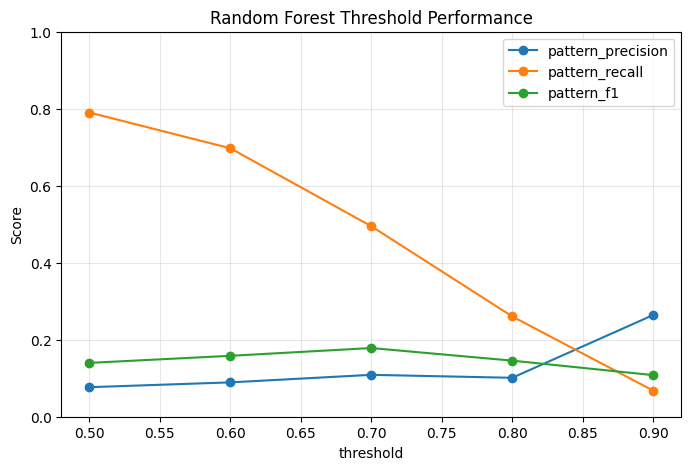

In [14]:
threshold_results.set_index("threshold")[["pattern_precision", "pattern_recall", "pattern_f1"]].plot(
    marker="o",
    figsize=(8, 5)
)

plt.title("Random Forest Threshold Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

In [15]:
best_f1_row = threshold_results.loc[threshold_results["pattern_f1"].idxmax()]

print("F1 기준 최적 threshold:")
print(best_f1_row)

F1 기준 최적 threshold:
threshold                      0.700000
accuracy                       0.696631
pattern_precision              0.108814
pattern_recall                 0.494806
pattern_f1                     0.178397
predicted_pattern_count    35896.000000
Name: 2, dtype: float64


In [16]:
best_threshold = best_f1_row["threshold"]

y_pred_rf_best = (y_proba_rf_plain >= best_threshold).astype(int)

print(f"Random Forest Best Threshold: {best_threshold}")

print(classification_report(
    y_test_encoded,
    y_pred_rf_best,
    target_names=label_info["class_name"].tolist()
))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_rf_best))

Random Forest Best Threshold: 0.7
              precision    recall  f1-score   support

 non_pattern       0.95      0.71      0.81    110701
     pattern       0.11      0.49      0.18      7894

    accuracy                           0.70    118595
   macro avg       0.53      0.60      0.50    118595
weighted avg       0.90      0.70      0.77    118595

Confusion Matrix:
[[78711 31990]
 [ 3988  3906]]


In [17]:
baseline_compare = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "threshold": "default",
        "accuracy": accuracy_score(y_test_encoded, y_pred_logistic),
        "pattern_precision": precision_score(y_test_encoded, y_pred_logistic, pos_label=1, zero_division=0),
        "pattern_recall": recall_score(y_test_encoded, y_pred_logistic, pos_label=1),
        "pattern_f1": f1_score(y_test_encoded, y_pred_logistic, pos_label=1),
        "predicted_pattern_count": np.sum(y_pred_logistic == 1)
    },
    {
        "model": "Random Forest",
        "threshold": best_threshold,
        "accuracy": accuracy_score(y_test_encoded, y_pred_rf_best),
        "pattern_precision": precision_score(y_test_encoded, y_pred_rf_best, pos_label=1, zero_division=0),
        "pattern_recall": recall_score(y_test_encoded, y_pred_rf_best, pos_label=1),
        "pattern_f1": f1_score(y_test_encoded, y_pred_rf_best, pos_label=1),
        "predicted_pattern_count": np.sum(y_pred_rf_best == 1)
    }
])

display(baseline_compare)

,model,threshold,accuracy,pattern_precision,pattern_recall,pattern_f1,predicted_pattern_count
0,Logistic Regression,default,0.569881,0.104875,0.724854,0.183239,54560
1,Random Forest,0.7,0.696631,0.108814,0.494806,0.178397,35896


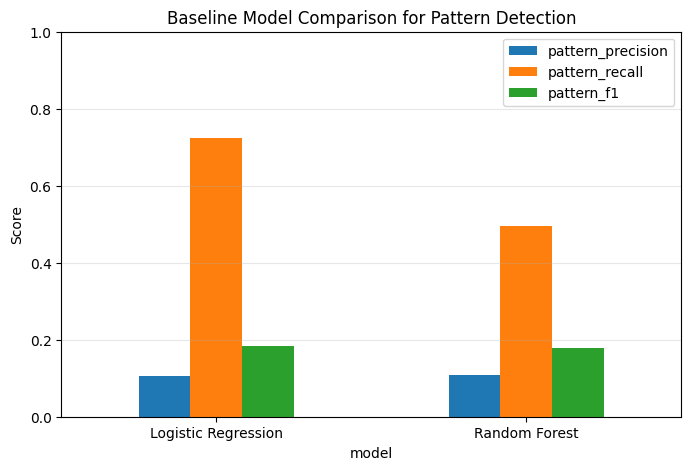

In [18]:
baseline_compare.set_index("model")[["pattern_precision", "pattern_recall", "pattern_f1"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Baseline Model Comparison for Pattern Detection")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Baseline Modeling 결과 해석

Logistic Regression과 Random Forest를 사용하여 `non_pattern`과 `pattern`을 분류하는 baseline 모델을 학습했다.

Logistic Regression은 pattern recall이 상대적으로 높아 실제 pattern wafer를 더 많이 탐지했지만, pattern precision이 낮아 오탐 부담이 컸다. Random Forest는 threshold를 조정하여 F1-score 기준 최적 threshold를 선택했으나, Logistic Regression 대비 뚜렷한 성능 개선을 보이지 않았다.

따라서 단순히 32x32 wafer map을 1차원 feature로 펼치는 baseline 방식은 wafer map의 공간 구조를 충분히 반영하지 못할 가능성이 있다. 이후 단계에서는 CNN 기반 모델을 사용하여 공간 패턴을 직접 학습하는 방식이 필요한지 검토한다.